# Inspect MAG7 Price Dataset Coverage

This notebook inspects the private Hugging Face dataset `cookekieran/mag7_prices` without modifying it. It answers:

- What files and columns are stored?
- Which MAG7 tickers are present?
- What date range is available for each ticker?
- Do all tickers stop being stored on the same date?
- Are there duplicate rows, missing values, or suspicious gaps?
- How continuous is collection near the end of the dataset?

`HF_TOKEN` is loaded from `.env`; no token is stored in this notebook.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from dotenv import load_dotenv
from huggingface_hub import HfApi, hf_hub_download

REPO_ID = "cookekieran/mag7_prices"
REPO_TYPE = "dataset"
EXPECTED_TICKERS = {"AAPL", "AMZN", "GOOGL", "META", "MSFT", "NVDA", "TSLA"}

load_dotenv(Path.cwd() / ".env")
HF_TOKEN = os.getenv("HF_TOKEN")
assert HF_TOKEN, "HF_TOKEN is missing. Add it to the local .env file."

api = HfApi(token=HF_TOKEN)
repo_info = api.repo_info(repo_id=REPO_ID, repo_type=REPO_TYPE)
REVISION = repo_info.sha
print(f"Repository: {REPO_ID}")
print(f"Pinned revision: {REVISION}")

Repository: cookekieran/mag7_prices
Pinned revision: 3b5925b8d5cb9a6eebbb315d9d708a6c28c19a36


## Repository files

In [2]:
repo_files = api.list_repo_files(repo_id=REPO_ID, repo_type=REPO_TYPE, revision=REVISION)
file_inventory = pd.DataFrame({"path": repo_files})
file_inventory["extension"] = file_inventory["path"].str.extract(r"(\.[^.]+)$", expand=False).fillna("")
display(file_inventory)

DATA_FILES = [p for p in repo_files if p.lower().endswith((".parquet", ".csv"))]
print(f"Found {len(DATA_FILES)} tabular data file(s).")

,path,extension
0,.gitattributes,.gitattributes
1,README.md,.md
2,mag7_daily_prices.parquet,.parquet


Found 1 tabular data file(s).


## Download and inspect schemas

In [3]:
tables = {}
for path_in_repo in DATA_FILES:
    local_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=path_in_repo,
        repo_type=REPO_TYPE,
        revision=REVISION,
        token=HF_TOKEN,
    )
    frame = pd.read_parquet(local_path) if path_in_repo.lower().endswith(".parquet") else pd.read_csv(local_path)
    tables[path_in_repo] = frame
    print(f"{path_in_repo}: {frame.shape[0]:,} rows x {frame.shape[1]} columns")
    print(frame.dtypes.to_string())
    display(frame.head(3))

mag7_daily_prices.parquet: 5,936 rows x 8 columns
date         datetime64[ns]
open                float64
high                float64
low                 float64
close               float64
adj_close           float64
volume                int64
ticker               object


,date,open,high,low,close,adj_close,volume,ticker
0,2023-01-03,14.851,14.996,14.096,14.315,14.299910,401277000,NVDA
1,2023-01-04,14.567,14.853,14.241,14.749,14.733453,431324000,NVDA
2,2023-01-05,14.491,14.564,14.148,14.265,14.249962,389168000,NVDA


## Build one canonical price table

In [4]:
price_frames = []
for source_file, frame in tables.items():
    lower_names = {str(c).lower(): c for c in frame.columns}
    if "ticker" not in lower_names:
        print(f"Skipping {source_file}: no ticker column")
        continue
    date_name = next((lower_names[c] for c in ("date", "datetime", "timestamp", "time") if c in lower_names), None)
    if date_name is None:
        print(f"Skipping {source_file}: no recognised date/time column")
        continue
    tidy = frame.copy()
    tidy = tidy.rename(columns={lower_names["ticker"]: "ticker", date_name: "date"})
    tidy["source_file"] = source_file
    price_frames.append(tidy)

assert price_frames, "No price-like table with ticker and date columns was found."
prices = pd.concat(price_frames, ignore_index=True)
prices["ticker"] = prices["ticker"].astype(str).str.upper().str.strip()
prices["date"] = pd.to_datetime(prices["date"], errors="coerce", utc=True).dt.tz_localize(None)
prices = prices.sort_values(["ticker", "date"]).reset_index(drop=True)

print(f"Combined rows: {len(prices):,}")
print(f"Tickers found: {sorted(prices['ticker'].dropna().unique())}")
print(f"Missing expected tickers: {sorted(EXPECTED_TICKERS - set(prices['ticker'].unique()))}")
display(prices.head())

Combined rows: 5,936
Tickers found: ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
Missing expected tickers: []


,date,open,high,low,close,adj_close,volume,ticker,source_file
0,2023-01-03,130.279999,130.899994,124.169998,125.070000,122.982712,112117500,AAPL,mag7_daily_prices.parquet
1,2023-01-04,126.889999,128.660004,125.080002,126.360001,124.251205,89113600,AAPL,mag7_daily_prices.parquet
2,2023-01-05,127.129997,127.769997,124.760002,125.019997,122.933556,80962700,AAPL,mag7_daily_prices.parquet
3,2023-01-06,126.010002,130.289993,124.889999,129.619995,127.456772,87754700,AAPL,mag7_daily_prices.parquet
4,2023-01-09,130.470001,133.410004,129.889999,130.149994,127.977913,70790800,AAPL,mag7_daily_prices.parquet


## Coverage and where storage stops

In [5]:
latest_overall = prices["date"].max()
coverage = prices.groupby("ticker").agg(
    rows=("date", "size"),
    valid_dates=("date", "count"),
    first_stored_date=("date", "min"),
    last_stored_date=("date", "max"),
    unique_dates=("date", "nunique"),
).reset_index()
coverage["days_behind_latest_ticker"] = (latest_overall - coverage["last_stored_date"]).dt.days
coverage["calendar_span_days"] = (coverage["last_stored_date"] - coverage["first_stored_date"]).dt.days + 1
coverage["rows_per_calendar_year"] = (coverage["rows"] / coverage["calendar_span_days"] * 365.25).round(1)
coverage = coverage.sort_values("ticker")

display(coverage)
print(f"Overall final stored timestamp/date: {latest_overall}")
print(f"All tickers stop together: {coverage['last_stored_date'].nunique() == 1}")

,ticker,rows,valid_dates,first_stored_date,last_stored_date,unique_dates,days_behind_latest_ticker,calendar_span_days,rows_per_calendar_year
0,AAPL,848,848,2023-01-03,2026-05-20,848,0,1234,251.0
1,AMZN,848,848,2023-01-03,2026-05-20,848,0,1234,251.0
2,GOOGL,848,848,2023-01-03,2026-05-20,848,0,1234,251.0
3,META,848,848,2023-01-03,2026-05-20,848,0,1234,251.0
4,MSFT,848,848,2023-01-03,2026-05-20,848,0,1234,251.0
5,NVDA,848,848,2023-01-03,2026-05-20,848,0,1234,251.0
6,TSLA,848,848,2023-01-03,2026-05-20,848,0,1234,251.0


Overall final stored timestamp/date: 2026-05-20 00:00:00
All tickers stop together: True


## Data quality checks

In [6]:
numeric_candidates = [c for c in ["open", "high", "low", "close", "adj_close", "volume"] if c in prices.columns]
duplicate_mask = prices.duplicated(["ticker", "date"], keep=False)
quality = prices.groupby("ticker").agg(
    duplicate_ticker_dates=("date", lambda s: int(pd.DataFrame({"ticker": prices.loc[s.index, "ticker"], "date": s}).duplicated().sum())),
    missing_dates=("date", lambda s: int(s.isna().sum())),
).reset_index()
for col in numeric_candidates:
    quality[f"missing_{col}"] = prices.groupby("ticker")[col].apply(lambda s: int(s.isna().sum())).values

display(quality)
print(f"Rows involved in duplicate ticker/date pairs: {int(duplicate_mask.sum()):,}")
if duplicate_mask.any():
    display(prices.loc[duplicate_mask].sort_values(["ticker", "date"]).head(30))

,ticker,duplicate_ticker_dates,missing_dates,missing_open,missing_high,missing_low,missing_close,missing_adj_close,missing_volume
0,AAPL,0,0,0,0,0,0,0,0
1,AMZN,0,0,0,0,0,0,0,0
2,GOOGL,0,0,0,0,0,0,0,0
3,META,0,0,0,0,0,0,0,0
4,MSFT,0,0,0,0,0,0,0,0
5,NVDA,0,0,0,0,0,0,0,0
6,TSLA,0,0,0,0,0,0,0,0


Rows involved in duplicate ticker/date pairs: 0


## Gaps between stored observations

In [7]:
gap_rows = []
for ticker, group in prices.dropna(subset=["date"]).groupby("ticker"):
    dates = group["date"].drop_duplicates().sort_values()
    gaps = dates.diff().dt.days
    for date, gap in zip(dates, gaps):
        if pd.notna(gap) and gap > 4:  # weekends normally create 3-day gaps
            gap_rows.append({"ticker": ticker, "next_stored_date": date, "gap_calendar_days": int(gap)})

gaps = pd.DataFrame(gap_rows)
if gaps.empty:
    print("No gaps longer than four calendar days were found.")
else:
    print(f"Found {len(gaps):,} gaps longer than four calendar days. Some will be exchange holidays.")
    display(gaps.sort_values("gap_calendar_days", ascending=False).head(30))

No gaps longer than four calendar days were found.


## Monthly continuity, especially near the end

ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
month,,,,,,,
2024-12-01,21,21,21,21,21,21,21
2025-01-01,20,20,20,20,20,20,20
2025-02-01,19,19,19,19,19,19,19
2025-03-01,21,21,21,21,21,21,21
2025-04-01,21,21,21,21,21,21,21
2025-05-01,21,21,21,21,21,21,21
2025-06-01,20,20,20,20,20,20,20
2025-07-01,22,22,22,22,22,22,22
2025-08-01,21,21,21,21,21,21,21


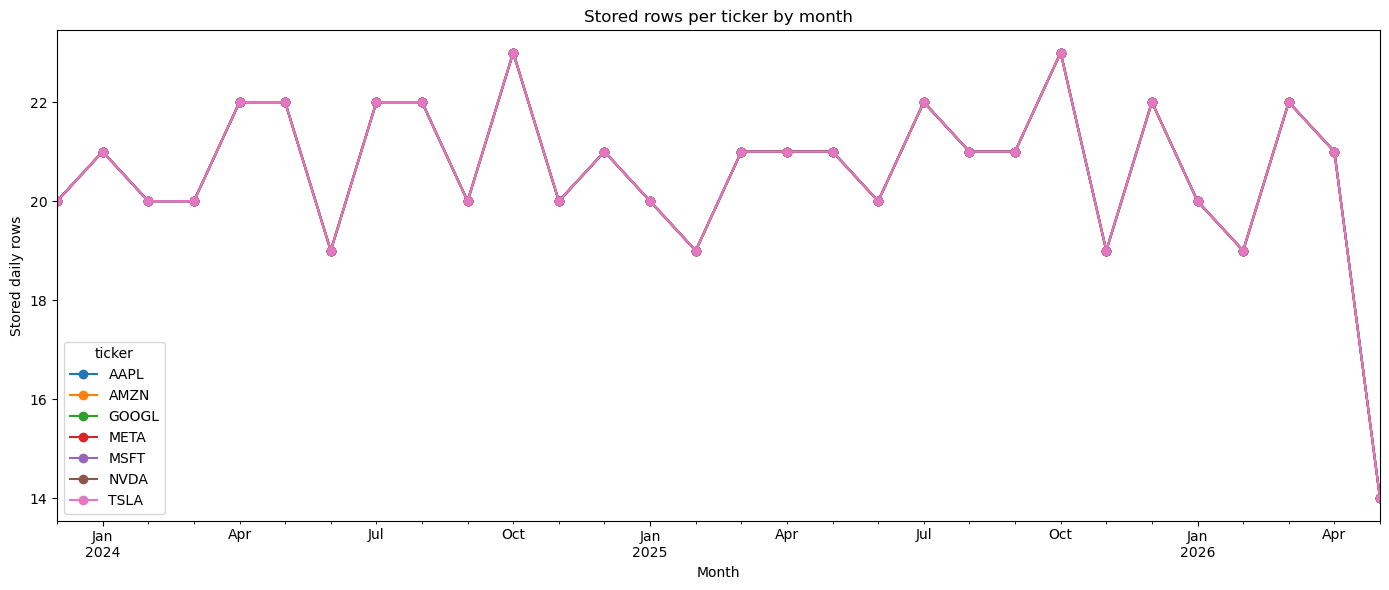

In [8]:
monthly = (prices.dropna(subset=["date"])
    .assign(month=lambda d: d["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "ticker"]).size().unstack(fill_value=0).sort_index())

display(monthly.tail(18))
ax = monthly.tail(30).plot(figsize=(14, 6), marker="o", title="Stored rows per ticker by month")
ax.set_ylabel("Stored daily rows")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

## Last stored observations

In [9]:
last_rows = prices.groupby("ticker", group_keys=False).tail(5)
cols = [c for c in ["ticker", "date", "open", "high", "low", "close", "adj_close", "volume", "source_file"] if c in last_rows.columns]
display(last_rows[cols].sort_values(["ticker", "date"]))

,ticker,date,open,high,low,close,adj_close,volume,source_file
843,AAPL,2026-05-14,299.820007,300.450012,295.380005,298.209991,298.209991,35324900,mag7_daily_prices.parquet
844,AAPL,2026-05-15,297.899994,303.200012,296.519989,300.230011,300.230011,54862800,mag7_daily_prices.parquet
845,AAPL,2026-05-18,300.239990,300.660004,294.910004,297.839996,297.839996,34483000,mag7_daily_prices.parquet
846,AAPL,2026-05-19,296.970001,300.510010,296.350006,298.970001,298.970001,42199700,mag7_daily_prices.parquet
847,AAPL,2026-05-20,298.179993,302.369995,298.089996,299.010010,299.010010,12565553,mag7_daily_prices.parquet
1691,AMZN,2026-05-14,269.149994,270.779999,266.630005,267.220001,267.220001,31338400,mag7_daily_prices.parquet
1692,AMZN,2026-05-15,262.500000,264.359985,260.890015,264.140015,264.140015,40770300,mag7_daily_prices.parquet
1693,AMZN,2026-05-18,263.869995,268.850006,262.529999,264.859985,264.859985,33690800,mag7_daily_prices.parquet
1694,AMZN,2026-05-19,262.040009,262.250000,255.190002,259.339996,259.339996,40269100,mag7_daily_prices.parquet
1695,AMZN,2026-05-20,260.049988,265.579987,259.532990,265.040009,265.040009,13540877,mag7_daily_prices.parquet


## Price history overview

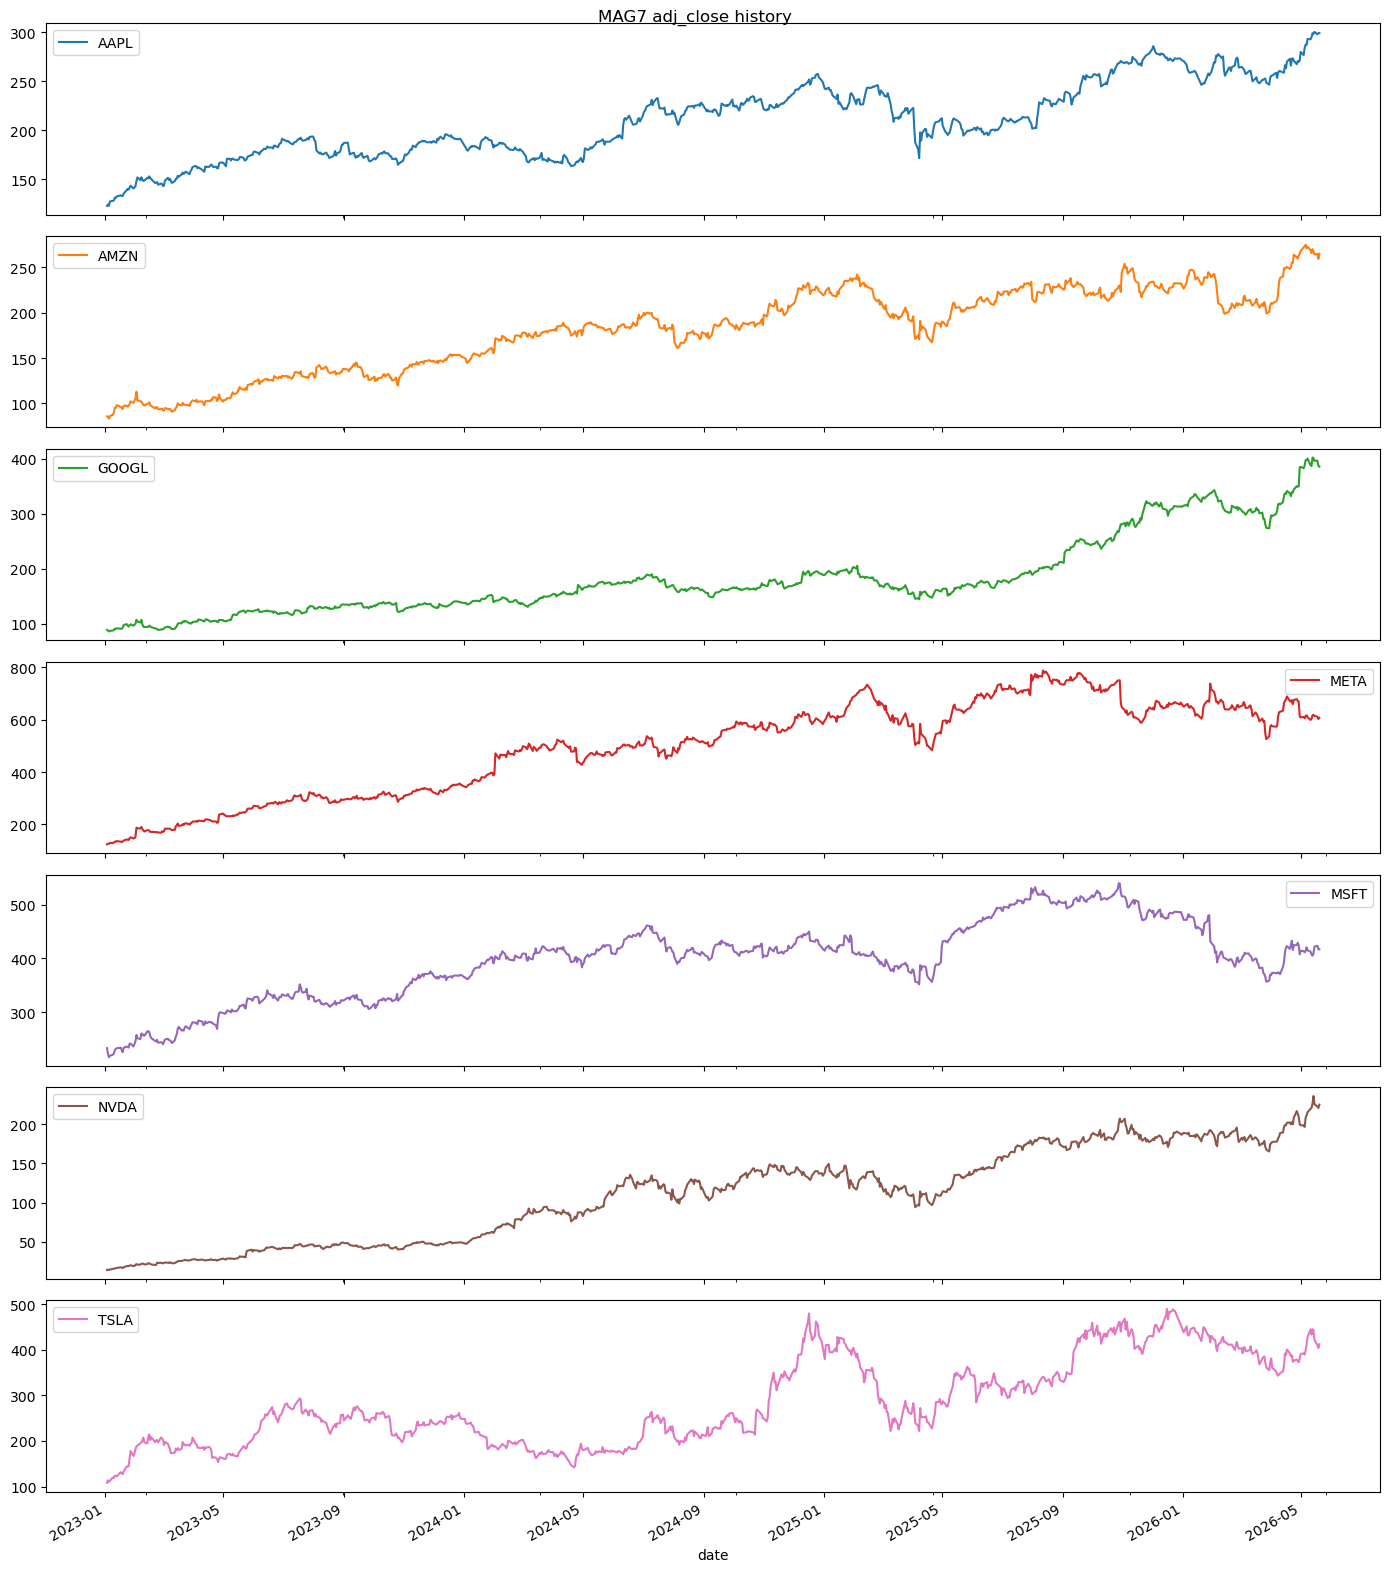

In [10]:
price_col = "adj_close" if "adj_close" in prices.columns else "close"
if price_col in prices.columns:
    chart = prices.pivot_table(index="date", columns="ticker", values=price_col, aggfunc="last")
    chart.plot(subplots=True, figsize=(14, 16), sharex=True, title=f"MAG7 {price_col} history")
    plt.tight_layout()
    plt.show()
else:
    print("No close or adjusted-close column was found for plotting.")

## Automated interpretation

In [11]:
print("DATASET COVERAGE SUMMARY")
print(f"- Repository revision inspected: {REVISION}")
print(f"- Rows: {len(prices):,}")
print(f"- Tickers: {', '.join(sorted(prices['ticker'].dropna().unique()))}")
print(f"- Earliest stored date: {prices['date'].min()}")
print(f"- Latest stored date: {prices['date'].max()}")
print(f"- All tickers have the same final date: {coverage['last_stored_date'].nunique() == 1}")
print(f"- Duplicate ticker/date rows: {int(duplicate_mask.sum()):,}")
print()
print("Final stored date by ticker:")
for row in coverage.itertuples():
    print(f"  {row.ticker}: {row.last_stored_date} ({row.rows:,} rows)")

print()
print("Interpretation note:")
print("The final stored date shows where this snapshot stops, but does not prove whether collection failed or was intentionally stopped.")
print("Compare the final date with the repository commit time and your collector schedule before treating later dates as missing.")

DATASET COVERAGE SUMMARY
- Repository revision inspected: 3b5925b8d5cb9a6eebbb315d9d708a6c28c19a36
- Rows: 5,936
- Tickers: AAPL, AMZN, GOOGL, META, MSFT, NVDA, TSLA
- Earliest stored date: 2023-01-03 00:00:00
- Latest stored date: 2026-05-20 00:00:00
- All tickers have the same final date: True
- Duplicate ticker/date rows: 0

Final stored date by ticker:
  AAPL: 2026-05-20 00:00:00 (848 rows)
  AMZN: 2026-05-20 00:00:00 (848 rows)
  GOOGL: 2026-05-20 00:00:00 (848 rows)
  META: 2026-05-20 00:00:00 (848 rows)
  MSFT: 2026-05-20 00:00:00 (848 rows)
  NVDA: 2026-05-20 00:00:00 (848 rows)
  TSLA: 2026-05-20 00:00:00 (848 rows)

Interpretation note:
The final stored date shows where this snapshot stops, but does not prove whether collection failed or was intentionally stopped.
Compare the final date with the repository commit time and your collector schedule before treating later dates as missing.
